<a href="https://colab.research.google.com/github/aryack2007/ict_assignments/blob/main/case_study1_arya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_csv('/content/athlete_events - medal.csv')
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246859,123601,Nataliya Andreyevna Ustinova,F,19.0,165.0,58.0,Soviet Union,URS,1964 Summer,1964.0,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
246860,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 100 metres Freestyle,NaN
246861,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,NaN
246862,123602,Tetiana Illivna Ustiuzhanina,F,27.0,185.0,78.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Rowing,Rowing Women's Quadruple Sculls,Bronze


PART 1- Data Understanding

Q1. Load the dataset

In [95]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [96]:
df.shape

(246864, 15)

In [97]:
print(df.columns) # displaying column names

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')


Q2.check data types

In [98]:
df.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,float64


In [99]:
num = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
print(num)


Numerical columns:
Index(['ID', 'Age', 'Height', 'Weight', 'Year'], dtype='object')


In [100]:
cat  = df.select_dtypes(include=['object']).columns
print("Categorical columns:")
print(cat)

Categorical columns:
Index(['Name', 'Sex', 'Team', 'NOC', 'Games', 'Season', 'City', 'Sport',
       'Event', 'Medal'],
      dtype='object')


Q3.Missing Values

In [101]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,8667
Height,54813
Weight,57347
Team,0
NOC,0
Games,0
Year,1


In [102]:
df['Medal'].unique()

array([nan, 'Gold', 'Bronze', 'Silver'], dtype=object)

PART 2 - Medal Filtering

Q4.create a new DataFrame containing only medal winners

In [103]:
medal_winners_df = df.dropna(subset=['Medal'])

In [104]:
display(medal_winners_df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


PART3-COUNTRY ANALYSIS

Q5.TOTAL MEDAL COUNT

In [105]:
top_10_countries = (
    medal_winners_df.groupby('NOC')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_countries)

NOC
USA    5161
URS    2271
GBR    1904
GER    1883
FRA    1714
ITA    1530
SWE    1433
CAN    1239
AUS    1219
HUN    1048
dtype: int64


Q6.Visualize top 10 countries

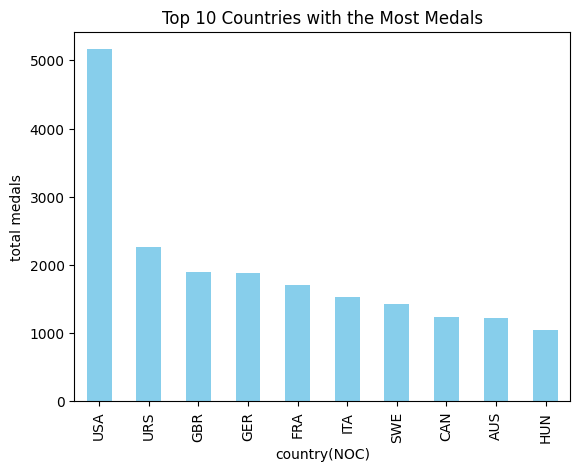

In [106]:
top_10_countries.plot(kind='bar',color='skyblue')
plt.title('Top 10 Countries with the Most Medals')
plt.xlabel('country(NOC)')
plt.ylabel('total medals')
plt.show()

Q7.Gold medal analysis

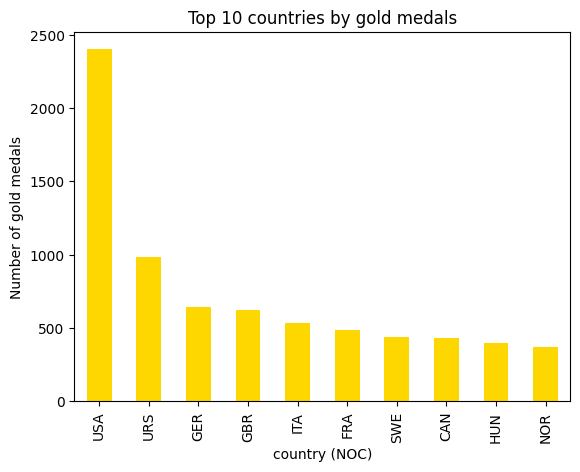

In [107]:
gold = medal_winners_df[medal_winners_df['Medal'] == 'Gold']
top_gold = gold['NOC'].value_counts().head(10)
top_gold.plot(kind='bar',color='gold')
plt.title('Top 10 countries by gold medals')
plt.xlabel('country (NOC)')
plt.ylabel('Number of gold medals')
plt.show()

Q8.Gender Distribution

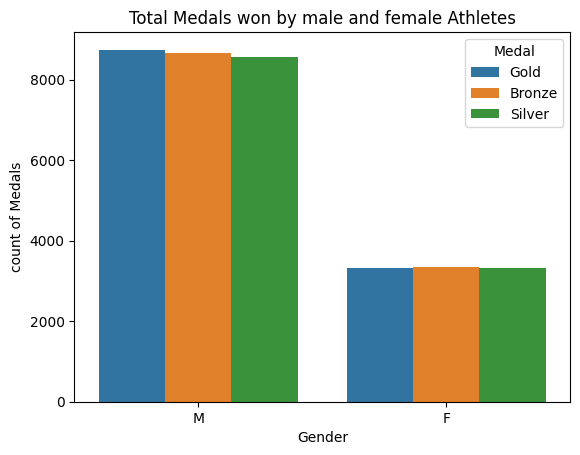

In [108]:
sns.countplot(data=medal_winners_df,x='Sex',hue='Medal')
plt.title('Total Medals won by male and female Athletes')
plt.xlabel('Gender')
plt.ylabel('count of Medals')
plt.show()

Q9.Gender trend over years

In [109]:
medal_counts = df.groupby(['Year','Sex']).size().reset_index(name='Medal_count')
medal_counts.head()

,Year,Sex,Medal_count
0,1896.0,M,348
1,1900.0,F,32
2,1900.0,M,1764
3,1904.0,F,13
4,1904.0,M,1146


part5- spot analysis

Q10.Top sports

In [110]:
top_10_sports = (
    medal_winners_df.groupby('Sport')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_sports)

Sport
Athletics     3654
Swimming      2717
Rowing        2683
Gymnastics    2049
Fencing       1599
Football      1439
Ice Hockey    1414
Hockey        1366
Wrestling     1178
Cycling       1131
dtype: int64


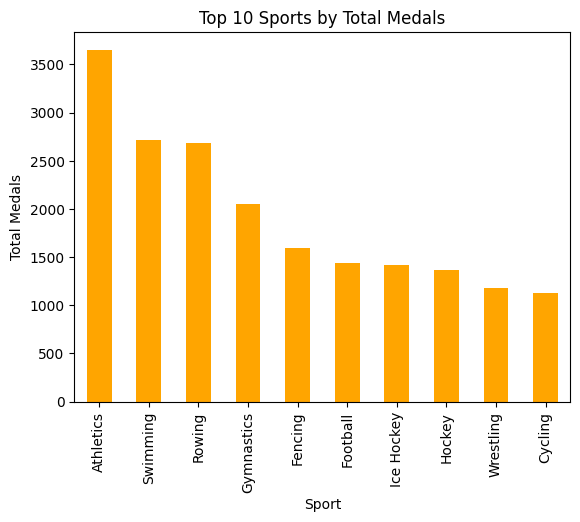

In [111]:
top_10_sports.plot(kind='bar', color='orange')
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medals')
plt.show()

PART 5- SPORTS ANALYSIS
q11GOLD MEDAL SPORT

In [112]:
gold_medal_sports = gold['Sport'].value_counts()
most_gold_sport = gold_medal_sports.idxmax()
num_gold_medals = gold_medal_sports.max()

print(f"The sport with the highest number of gold medals is {most_gold_sport} with {num_gold_medals} gold medals.")

The sport with the highest number of gold medals is Athletics with 1230 gold medals.


Q12 medal trend overtime

In [113]:
medals_per_year = medal_winners_df.groupby('Year').size()
print(medals_per_year.head())

Year
1896.0    129
1900.0    555
1904.0    431
1906.0    420
1908.0    764
dtype: int64


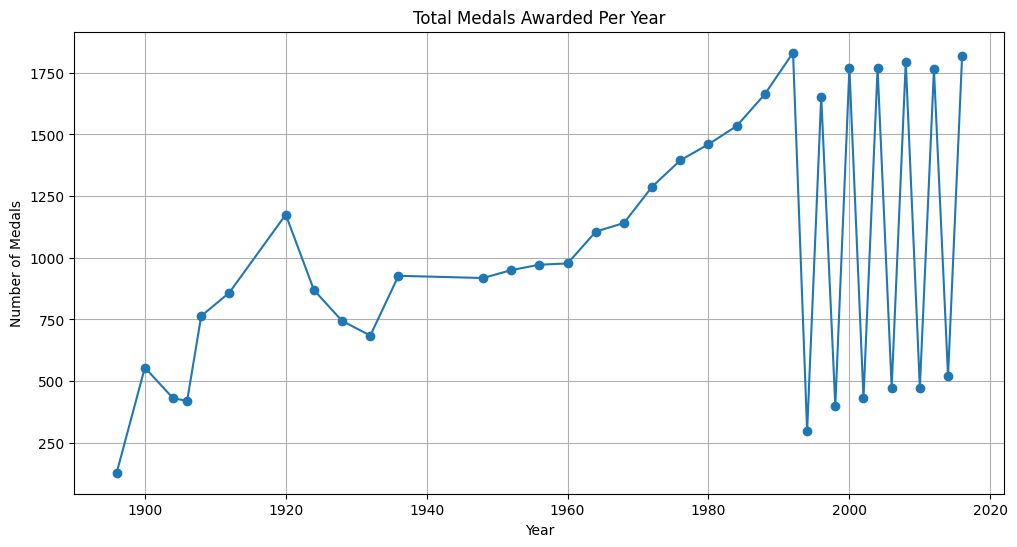

In [114]:
plt.figure(figsize=(12, 6))
medals_per_year.plot(kind='line', marker='o')
plt.title('Total Medals Awarded Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.show()

13. best olympic year

In [115]:
best_olympic_year = medals_per_year.idxmax()
highest_medals = medals_per_year.max()

print(f"The year with the highest number of medals awarded was {best_olympic_year} with {highest_medals} medals.")

The year with the highest number of medals awarded was 1992.0 with 1831 medals.


Q14.Age distribution

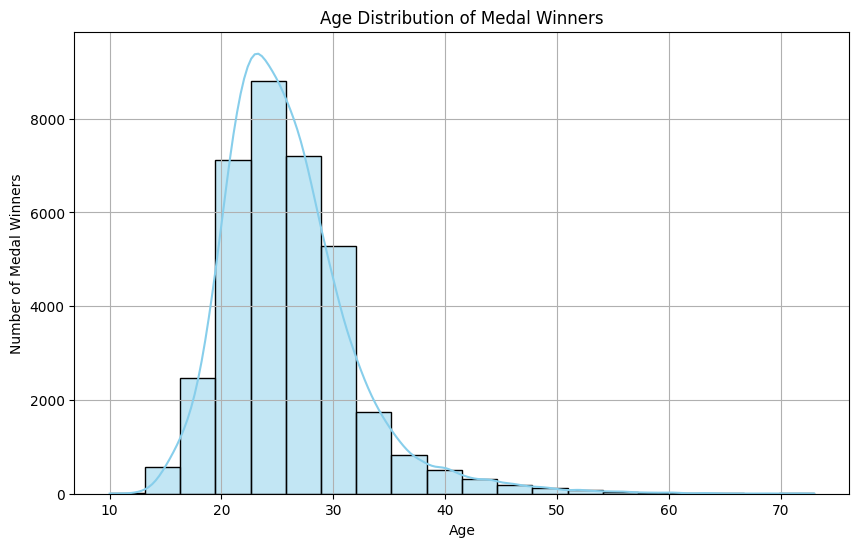

In [121]:
plt.figure(figsize=(10, 6))
sns.histplot(medal_winners_df['Age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Medal Winners')
plt.xlabel('Age')
plt.ylabel('Number of Medal Winners')
plt.grid(True)
plt.show()

Q15.Average age by medal type

In [122]:
average_age_by_medal = medal_winners_df.groupby('Medal')['Age'].mean().dropna()
print(average_age_by_medal)

Medal
Bronze    25.902074
Gold      25.906690
Silver    26.027022
Name: Age, dtype: float64


paRT 8
q16 CORRELATION MATRIX

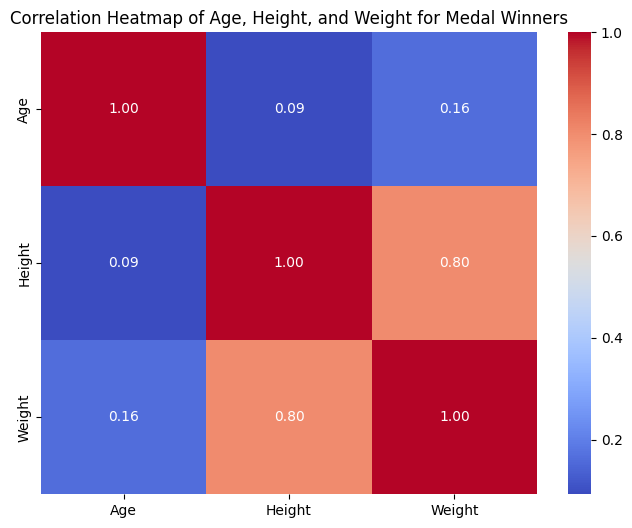

In [123]:
numerical_cols = ['Age', 'Height', 'Weight']
correlation_matrix = medal_winners_df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Age, Height, and Weight for Medal Winners')
plt.show()

PART9
Q17.COUNTRY PERFORMANCE

In [125]:
india_total_medals = medal_winners_df[medal_winners_df['NOC'] == 'IND'].shape[0]
india_gold_medals = gold[gold['NOC'] == 'IND'].shape[0]

print(f"India has won a total of {india_total_medals} medals.")
print(f"India has won {india_gold_medals} gold medals.")

India has won a total of 195 medals.
India has won 136 gold medals.


q18 SPORT DEEP DIVE

In [126]:
athletics_df = medal_winners_df[medal_winners_df['Sport'] == 'Athletics']
display(athletics_df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
163,67,Mariya Vasilyevna Abakumova (-Tarabina),F,22.0,179.0,80.0,Russia,RUS,2008 Summer,2008.0,Summer,Beijing,Athletics,Athletics Women's Javelin Throw,Silver
191,86,Jos Manuel Abascal Gmez,M,26.0,182.0,67.0,Spain,ESP,1984 Summer,1984.0,Summer,Los Angeles,Athletics,"Athletics Men's 1,500 metres",Bronze
620,359,Andrey Khakimovich Abduvaliyev,M,26.0,190.0,125.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Athletics,Athletics Men's Hammer Throw,Gold
655,379,Addis Abebe,M,21.0,160.0,50.0,Ethiopia,ETH,1992 Summer,1992.0,Summer,Barcelona,Athletics,"Athletics Men's 10,000 metres",Bronze
720,411,Gezahgne Abera,M,22.0,166.0,58.0,Ethiopia,ETH,2000 Summer,2000.0,Summer,Sydney,Athletics,Athletics Men's Marathon,Gold


In [128]:
gender_trends_athletics = athletics_df.groupby(['Year', 'Sex']).size().unstack(fill_value=0)
display(gender_trends_athletics.head())

Sex,F,M
Year,,
1896.0,0,35
1900.0,0,76
1904.0,0,71
1906.0,0,65
1908.0,0,93


<Figure size 1200x600 with 0 Axes>

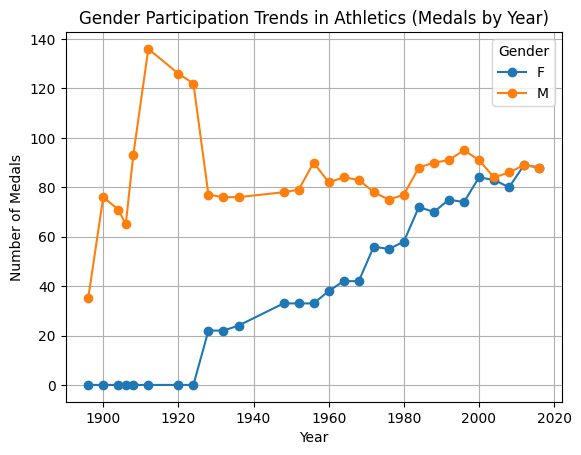

In [129]:
plt.figure(figsize=(12, 6))
gender_trends_athletics.plot(kind='line', marker='o')
plt.title('Gender Participation Trends in Athletics (Medals by Year)')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.legend(title='Gender')
plt.show()

Q19. top 5 yougest gold medalist

In [132]:
youngest_gold_medalists = gold.sort_values(by='Age').dropna(subset=['Age']).head(5)
display(youngest_gold_medalists[['Name', 'Age', 'Sport', 'NOC']])

,Name,Age,Sport,NOC
78544,Marjorie Gestring (-Redlick),13.0,Diving,USA
73581,Fu Mingxia,13.0,Diving,CHN
52010,Donna Elizabeth de Varona (-Pinto),13.0,Swimming,USA
200704,Aileen Muriel Riggin (-Soule),13.0,Diving,USA
119277,Kim Yun-Mi,13.0,Short Track Speed Skating,KOR


Q20.